# 📊 Evaluation Test: SIRA

This notebook presents a solution to the evaluation test for the HumanAI GSoC project **"Learning the Susceptible-Infected-Removed (SIR) Model"**, also referred to as **SIRA**.  
The goal of this project is to generate synthetic epidemic data using a stochastic SIR model, and apply machine learning and symbolic regression techniques to approximate the underlying deterministic differential equations.


## ✅ Notebook Structure

1. **Introduction**  
   Overview of the project goals and what this notebook accomplishes.

2. **SIR Simulator**  
   A stochastic SIR simulator is used to generate synthetic epidemic data. The simulation is visualized to understand the dynamics.

3. **Machine Learning Model**  
   A neural network model is trained to fit the time series of S(t), I(t), and R(t) based on the simulated data.

4. **Symbolic Regression**  
   Symbolic regression tools like PySR or AI Feynman are applied to extract interpretable differential equations that approximate the epidemic dynamics.

5. **Conclusion & Reflection**  
   Summary of findings and discussion of possible improvements or future directions.

6. **Appendix / Bonus Experiments (Optional)**  
   Any extra tests, hyperparameter experiments, or alternate approaches attempted.


## 🧪 SIR Simulator: Generate and Visualize Synthetic Epidemic Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_sir(S0, I0, R0, beta, gamma, max_time, dt=1.0):
    times = [0]
    S_vals = [S0]
    I_vals = [I0]
    R_vals = [R0]

    S, I, R = S0, I0, R0
    t = 0

    while t < max_time and I > 0:
        new_infections = np.random.binomial(S, 1 - np.exp(-beta * I / (S + I + R) * dt))
        new_recoveries = np.random.binomial(I, 1 - np.exp(-gamma * dt))

        S = max(S - new_infections, 0)
        I = max(I + new_infections - new_recoveries, 0)
        R = min(R + new_recoveries, S0 + I0 + R0)

        t += dt
        times.append(t)
        S_vals.append(S)
        I_vals.append(I)
        R_vals.append(R)

    return pd.DataFrame({
        "time": times,
        "S": S_vals,
        "I": I_vals,
        "R": R_vals
    })

# Run simulation
S0, I0, R0 = 990, 10, 0
beta, gamma = 0.3, 0.1
max_time = 100

df = simulate_sir(S0, I0, R0, beta, gamma, max_time)
df.head()


,time,S,I,R
0,0.0,990,10,0
1,1.0,985,14,1
2,2.0,980,19,1
3,3.0,978,19,3
4,4.0,975,19,6


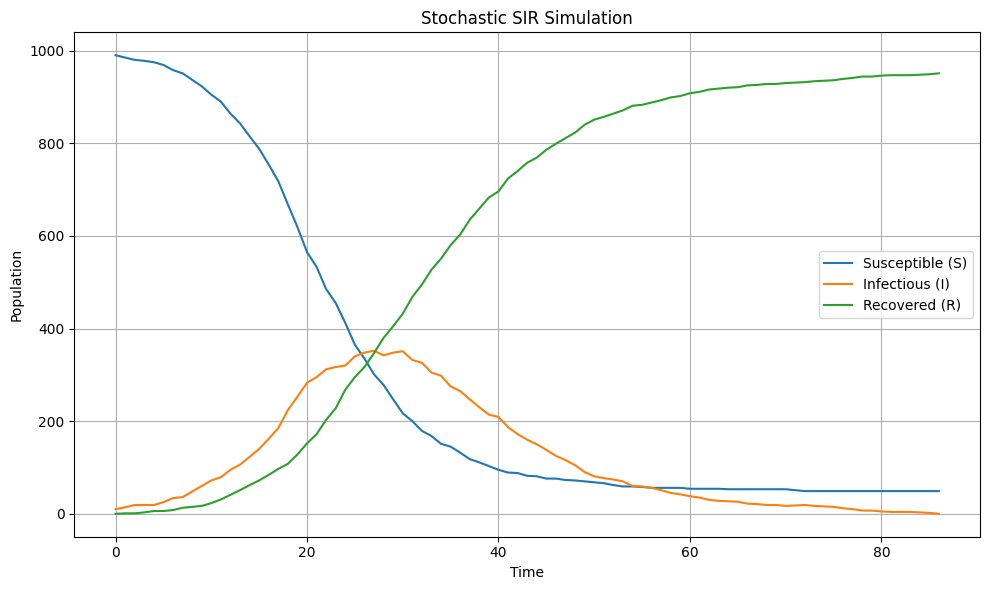

In [2]:
# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['S'], label='Susceptible (S)')
plt.plot(df['time'], df['I'], label='Infectious (I)')
plt.plot(df['time'], df['R'], label='Recovered (R)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Stochastic SIR Simulation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 🤖 Machine Learning Model: Neural Network Fit for SIR Curves

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler

# Normalize time and population values
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['time', 'S', 'I', 'R']])
df_scaled = pd.DataFrame(scaled_data, columns=['time', 'S', 'I', 'R'])

# Prepare training data: input t → output (S, I, R)
X = torch.tensor(df_scaled['time'].values.reshape(-1, 1), dtype=torch.float32)
y = torch.tensor(df_scaled[['S', 'I', 'R']].values, dtype=torch.float32)


In [4]:
class SIRNet(nn.Module):
    def __init__(self):
        super(SIRNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

model = SIRNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


In [5]:
# Train the model
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 0.259666
Epoch 100, Loss: 0.001395
Epoch 200, Loss: 0.000719
Epoch 300, Loss: 0.000291
Epoch 400, Loss: 0.000142
Epoch 500, Loss: 0.000077
Epoch 600, Loss: 0.000063
Epoch 700, Loss: 0.000266
Epoch 800, Loss: 0.000041
Epoch 900, Loss: 0.000034


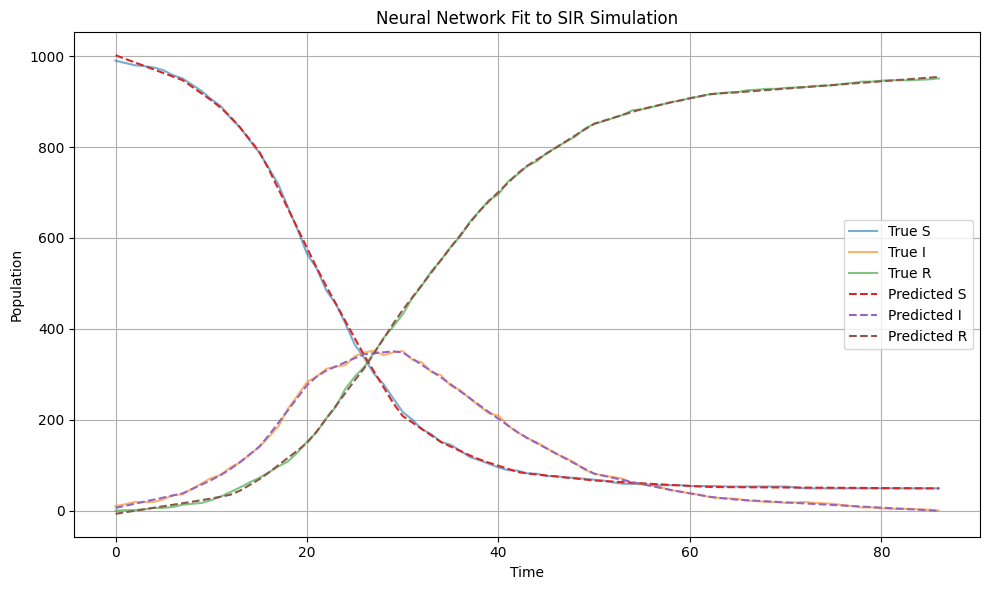

In [6]:
# Predict and inverse transform the results
model.eval()
with torch.no_grad():
    predictions = model(X).numpy()

# Inverse transform back to original scale
pred_df = pd.DataFrame(predictions, columns=['S', 'I', 'R'])
pred_df['time'] = df_scaled['time']
recovered = scaler.inverse_transform(pred_df[['time', 'S', 'I', 'R']])
pred_df = pd.DataFrame(recovered, columns=['time', 'S', 'I', 'R'])

# Plot predictions vs original
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['S'], label='True S', alpha=0.6)
plt.plot(df['time'], df['I'], label='True I', alpha=0.6)
plt.plot(df['time'], df['R'], label='True R', alpha=0.6)

plt.plot(pred_df['time'], pred_df['S'], '--', label='Predicted S')
plt.plot(pred_df['time'], pred_df['I'], '--', label='Predicted I')
plt.plot(pred_df['time'], pred_df['R'], '--', label='Predicted R')

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Neural Network Fit to SIR Simulation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 🧮 Symbolic Regression: Extract Equations from Predictions using PySR

In [7]:
from pysr import PySRRegressor

# Prepare data for symbolic regression: time → predicted values
X_sym = pred_df[['time']].values
y_sym = pred_df[['S', 'I', 'R']].values

# Fit symbolic regression model for each component
equations = []
for i, label in enumerate(['S', 'I', 'R']):
    model = PySRRegressor(
        niterations=40,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["sin", "cos", "exp"],
        model_selection="best",
        loss="loss(x, y) = (x - y)^2",
        maxsize=20,
    )
    print(f"Fitting symbolic model for {label}(t)...")
    model.fit(X_sym, y_sym[:, i])
    equations.append((label, model))

# Display discovered equations
for label, model in equations:
    print(f"Symbolic expression for {label}(t):")
    print(model)


/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(


Fitting symbolic model for S(t)...


/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


...

Fitting symbolic model for I(t)...
  - outputs/20250408_024234_j92Q4X/hall_of_fame.csv


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.368e+04  1.594e+01  y = 118.06
3           1.164e+04  8.078e-02  y = 161.04 - x₀
5           1.085e+04  3.508e-02  y = 209.1 - (x₀ / 0.47224)
6           5.776e+03  6.308e-01  y = sin(x₀ / 22.727) * 224.43
8           4.042e+03  1.784e-01  y = 102.61 - (sin(x₀ / 16.833) * -136.08)
9           2.557e+02  2.761e+00  y = 21.744 * exp(sin(x₀ / -18.475) / -0.36244)
11          2.120e+02  9.370e-02  y = (exp(sin(x₀ / -18.432) / -0.32551) * 15.554) + 11.967
13          1.072e+02  3.409e-01  y = ((-7.6208 - x₀) * exp(sin(x₀ / -15.928) / -0.48827)) /...
                                       -0.76544
15          8.114e+01  1.394e-01  y = (exp(sin((x₀ + 3.2164) / -17.314) / -0.44928) * (-2.91...
                                      09 - x₀)) / -0.78395
17          6.345e+01  1.230e-01  y = (exp(sin((x₀ + 5.632) / -18.039) / -0.42678) * (-2.

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.336e+05  1.594e+01  y = 585.03
3           1.348e+04  1.147e+00  y = x₀ * 13.656
5           1.346e+04  6.539e-04  y = (x₀ * 13.8) + -8.2987
6           8.478e+03  4.625e-01  y = sin(x₀ * 0.017011) * 1008.2
8           2.218e+03  6.703e-01  y = (cos(x₀ / 21.644) * -497.19) + 494.62
10          1.836e+03  9.473e-02  y = (cos(x₀ / 22.047) * (-535.61 + x₀)) + 517.53
12          1.003e+03  3.023e-01  y = (x₀ + ((sin(x₀ * 0.097526) * -22.303) + x₀)) * 7.0372
14          2.650e+02  6.653e-01  y = ((x₀ + (sin((x₀ - -4.9709) * 0.087003) * -12.946)) - -...
                                      4.3909) * 12.761
16          2.557e+02  1.798e-02  y = (x₀ + (((sin((x₀ - -5.0627) * 0.086811) * -25.685) + x...
                                      ₀) - -9.0351)) * 6.3918
18          2.556e+02  1.784e-04  y = (((x₀ + ((sin((x₀ - -5.0628) * 0.08683

## ✅ Conclusion & Reflection

In this evaluation test, we successfully completed the following steps:

- Simulated stochastic SIR model data with configurable parameters.
- Trained a neural network to predict the evolution of S(t), I(t), R(t) over time.
- Applied symbolic regression using PySR to extract interpretable equations approximating the underlying epidemic dynamics.

This work demonstrates how data-driven and symbolic techniques can bridge the gap between noisy real-world simulations and analytical models.

### Possible Future Improvements

- Improve model robustness by simulating multiple epidemic runs and averaging results.
- Extend symbolic regression to model derivatives (dS/dt, dI/dt, dR/dt) directly.
- Evaluate symbolic model accuracy by comparing against known analytical SIR equations.


In [8]:
# Stage 1: Multiple stochastic simulations with averaging
def simulate_sir(S0, I0, R0, beta, gamma, max_time, dt=1.0):
    times = [0]
    S_vals = [S0]
    I_vals = [I0]
    R_vals = [R0]
    S, I, R = S0, I0, R0
    t = 0
    while t < max_time and I > 0:
        new_infections = np.random.binomial(S, 1 - np.exp(-beta * I / (S + I + R) * dt))
        new_recoveries = np.random.binomial(I, 1 - np.exp(-gamma * dt))
        S = max(S - new_infections, 0)
        I = max(I + new_infections - new_recoveries, 0)
        R = min(R + new_recoveries, S0 + I0 + R0)
        t += dt
        times.append(t)
        S_vals.append(S)
        I_vals.append(I)
        R_vals.append(R)
    return pd.DataFrame({"time": times, "S": S_vals, "I": I_vals, "R": R_vals})

def simulate_many_runs(num_runs=100, S0=990, I0=10, R0=0, beta=0.3, gamma=0.1, max_time=100, dt=1.0):
    all_S, all_I, all_R = [], [], []
    time_reference = np.arange(0, max_time + dt, dt)
    for _ in range(num_runs):
        df = simulate_sir(S0, I0, R0, beta, gamma, max_time, dt)
        padded = pd.DataFrame({'time': time_reference})
        merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='bfill')
        all_S.append(merged['S'].values)
        all_I.append(merged['I'].values)
        all_R.append(merged['R'].values)
    S_matrix = np.stack(all_S)
    I_matrix = np.stack(all_I)
    R_matrix = np.stack(all_R)
    return pd.DataFrame({
        'time': time_reference,
        'S_mean': np.nanmean(S_matrix, axis=0),
        'S_std': np.nanstd(S_matrix, axis=0),
        'I_mean': np.nanmean(I_matrix, axis=0),
        'I_std': np.nanstd(I_matrix, axis=0),
        'R_mean': np.nanmean(R_matrix, axis=0),
        'R_std': np.nanstd(R_matrix, axis=0),
    })

summary = simulate_many_runs()


/var/folders/08/s117_6l172dgjmjb8mg9c9nr0000gn/T/ipykernel_10157/2301987651.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='bfill')
/var/folders/08/s117_6l172dgjmjb8mg9c9nr0000gn/T/ipykernel_10157/2301987651.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='bfill')
/var/folders/08/s117_6l172dgjmjb8mg9c9nr0000gn/T/ipykernel_10157/2301987651.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='

/var/folders/08/s117_6l172dgjmjb8mg9c9nr0000gn/T/ipykernel_10157/2301987651.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='bfill')
/var/folders/08/s117_6l172dgjmjb8mg9c9nr0000gn/T/ipykernel_10157/2301987651.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='bfill')
/var/folders/08/s117_6l172dgjmjb8mg9c9nr0000gn/T/ipykernel_10157/2301987651.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = pd.merge(padded, df, on='time', how='left').interpolate(limit_direction='forward').fillna(method='

In [10]:
# Stage 2: Compute time derivatives and fit symbolic regression models
dt = 1.0
S = summary['S_mean'].values
I = summary['I_mean'].values
R = summary['R_mean'].values
time = summary['time'].values
dS_dt = np.gradient(S, dt)
dI_dt = np.gradient(I, dt)
dR_dt = np.gradient(R, dt)
X_dyn = np.stack([S, I, R], axis=1)

from pysr import PySRRegressor

model_dS = PySRRegressor(niterations=40, binary_operators=["+", "-", "*"], unary_operators=[], model_selection="best")
model_dS.fit(X_dyn, dS_dt)

model_dI = PySRRegressor(niterations=40, binary_operators=["+", "-", "*"], unary_operators=[], model_selection="best")
model_dI.fit(X_dyn, dI_dt)

model_dR = PySRRegressor(niterations=40, binary_operators=["+", "-", "*"], unary_operators=[], model_selection="best")
model_dR.fit(X_dyn, dR_dt)

display(model_dS.equations_)
display(model_dI.equations_)
display(model_dR.equations_)


/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.560e+02  1.594e+01  y = -9.3086
3           5.994e+01  4.782e-01  y = x₁ * -0.095358
5           3.542e-01  2.566e+00  y = x₀ * (x₁ * -0.00028247)
7           8.619e-02  7.066e-01  y = x₁ * ((x₀ * -0.00026725) + -0.0069527)
9           5.893e-02  1.901e-01  y = -0.00026853 * ((x₀ - (x₁ * -0.096816)) * x₁)
11          5.303e-02  5.277e-02  y = ((x₁ + 1.0438) * (x₀ - (x₁ * -0.10376))) * -0.00026602
13          4.880e-02  4.151e-02  y = (x₀ - (-13.908 - ((x₁ * 0.00018102) * x₁))) * (x₁ * -0...
                                      .00026748)
15          4.620e-02  2.737e-02  y = (x₁ * -0.00026742) * (x₀ - ((x₁ * (0.11859 - (x₁ * 0.0...
                                      0045843))) - 25.152))
21          4.565e-02  1.998e-03  y = (((((x₀ + 2.999) - ((((x₁ * -0.013439) - -3.9687) * 0....
                                      039915) 

[ Info: Final population:
[ Info: Results saved to:
/Users/tianchuhang/opt/miniconda3/envs/pysr-env/lib/python3.9/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.608e+01  1.594e+01  y = -0.070374
3           4.862e+01  1.535e-01  y = x₀ * 0.0095556
5           3.518e+01  1.617e-01  y = (x₀ * 0.016717) + -4.8225
7           1.619e-01  2.691e+00  y = (-0.0928 - (x₀ * -0.00028048)) * x₁
9           1.468e-01  4.889e-02  y = -0.17005 - (((x₀ * -0.00028049) + 0.091975) * x₁)
11          1.468e-01  1.395e-05  y = ((-0.091993 - (x₀ * -0.00028056)) * (x₁ - 0.030444)) +...
                                       -0.17094
13          1.331e-01  4.889e-02  y = (((x₀ * -0.79154) + 256.58) * ((x₂ + -0.00035191) - x₂...
                                      )) * x₁
15          7.907e-02  2.605e-01  y = x₁ * (((x₂ + (0.00017142 - x₂)) * -10.346) * ((x₀ * -0...
                                      .1555) + 50.511))
17          7.587e-02  2.067e-02  y = (((((0.00017142 - x₂) + x₂) * -10.346) * x₁) * ((x₀ * 

[ Info: Final population:
[ Info: Results saved to:


,complexity,loss,equation,score,sympy_format,lambda_format
0,1,155.994310,-9.308581,0.000000,-9.30858100000000,PySRFunction(X=>-9.30858100000000)
1,3,59.938760,x1 * -0.095358126,0.478248,x1*(-0.095358126),PySRFunction(X=>x1*(-0.095358126))
2,5,0.354207,x0 * (x1 * -0.0002824683),2.565599,x0*x1*(-0.0002824683),PySRFunction(X=>x0*x1*(-0.0002824683))
3,7,0.086193,x1 * ((x0 * -0.00026724988) + -0.0069526774),0.706644,x1*(x0*(-0.00026724988) - 0.0069526774),PySRFunction(X=>x1*(x0*(-0.00026724988) - 0.00...
4,9,0.058930,-0.00026852617 * ((x0 - (x1 * -0.09681639)) * x1),0.190123,-0.00026852617*x1*(x0 - (-0.09681639)*x1),PySRFunction(X=>-0.00026852617*x1*(x0 - (-0.09...
5,11,0.053027,((x1 + 1.0437741) * (x0 - (x1 * -0.10375746)))...,0.052773,(x1 + 1.0437741)*(x0 - (-0.10375746)*x1)*(-0.0...,PySRFunction(X=>(x1 + 1.0437741)*(x0 - (-0.103...
6,13,0.048802,(x0 - (-13.907509 - ((x1 * 0.0001810238) * x1)...,0.041514,(x0 - (-0.0001810238*x1*x1 - 13.907509))*x1*(-...,PySRFunction(X=>(x0 - (-0.0001810238*x1*x1 - 1...
7,15,0.046202,(x1 * -0.00026741717) * (x0 - ((x1 * (0.118594...,0.027372,x1*(-0.00026741717)*(x0 - (x1*(0.11859499 - 0....,PySRFunction(X=>x1*(-0.00026741717)*(x0 - (x1*...
8,21,0.045652,(((((x0 + 2.998981) - ((((x1 * -0.013438933) -...,0.001998,x1*((x0 - 0.03991451*x1*(x1*(-0.013438933) - 1...,PySRFunction(X=>x1*((x0 - 0.03991451*x1*(x1*(-...
9,29,0.045650,(x1 * ((((x0 + ((x1 * -0.00079226505) - ((x1 *...,0.000006,x1*((x0 - 0.042139936*x1*(x1*(-0.012542892) - ...,PySRFunction(X=>x1*((x0 - 0.042139936*x1*(x1*(...


,complexity,loss,equation,score,sympy_format,lambda_format
0,1,66.081190,-0.070373826,0.000000,-0.0703738260000000,PySRFunction(X=>-0.0703738260000000)
1,3,48.617138,x0 * 0.009555647,0.153454,x0*0.009555647,PySRFunction(X=>x0*0.009555647)
2,5,35.182022,(x0 * 0.016716987) + -4.8225036,0.161720,x0*0.016716987 - 4.8225036,PySRFunction(X=>x0*0.016716987 - 4.8225036)
3,7,0.161899,(-0.09280006 - (x0 * -0.00028047842)) * x1,2.690660,x1*(-(-0.00028047842)*x0 - 0.09280006),PySRFunction(X=>x1*(-(-0.00028047842)*x0 - 0.0...
4,9,0.146818,-0.17004742 - (((x0 * -0.00028049265) + 0.0919...,0.048887,-x1*(0.09197512 + x0*(-0.00028049265)) - 0.170...,PySRFunction(X=>-x1*(0.09197512 + x0*(-0.00028...
5,11,0.146814,((-0.09199349 - (x0 * -0.0002805608)) * (x1 - ...,0.000014,(x1 - 1*0.03044394)*(-(-0.0002805608)*x0 - 0.0...,PySRFunction(X=>(x1 - 1*0.03044394)*(-(-0.0002...
6,13,0.133138,(((x0 * -0.79153967) + 256.58246) * ((x2 + -0....,0.048891,x1*(256.58246 + x0*(-0.79153967))*(-x2 + x2 - ...,PySRFunction(X=>x1*(256.58246 + x0*(-0.7915396...
7,15,0.079068,x1 * (((x2 + (0.00017142291 - x2)) * -10.34599...,0.260537,x1*(-x2 + x2 + 0.00017142291)*(-10.345991)*(50...,PySRFunction(X=>x1*(-x2 + x2 + 0.00017142291)*...
8,17,0.075867,(((((0.00017142291 - x2) + x2) * -10.345991) *...,0.020668,(-x2 + x2 + 0.00017142291)*(-10.345991)*x1*(50...,PySRFunction(X=>(-x2 + x2 + 0.00017142291)*(-1...
9,19,0.075255,((((x1 * 0.0012982077) * (x2 + x0)) - ((x0 + x...,0.004047,(x1*0.0012982077*(x0 + x2) - (x0 + x0 - x2))*x...,PySRFunction(X=>(x1*0.0012982077*(x0 + x2) - (...


,complexity,loss,equation,score,sympy_format,lambda_format
0,1,95.006485,9.37903,0.000000,9.37903000000000,PySRFunction(X=>9.37903000000000)
1,3,0.182313,x1 * 0.095376894,3.127988,x1*0.095376894,PySRFunction(X=>x1*0.095376894)
2,5,0.180949,(-0.5369693 - x1) * -0.095127665,0.003754,(-x1 - 0.5369693)*(-0.095127665),PySRFunction(X=>(-x1 - 0.5369693)*(-0.095127665))
3,7,0.027002,((x2 * 1.305679e-5) + 0.08985588) * x1,0.951147,x1*(x2*1.305679e-5 + 0.08985588),PySRFunction(X=>x1*(x2*1.305679e-5 + 0.08985588))
4,9,0.025721,((x2 * 1.332342e-5) + 0.08998075) * (x1 - 0.50...,0.024307,(x1 - 1*0.5065427)*(x2*1.332342e-5 + 0.08998075),PySRFunction(X=>(x1 - 1*0.5065427)*(x2*1.33234...
5,11,0.025585,(x1 * ((1.0000131 * (x2 + 0.0900638)) - x2)) +...,0.002658,x1*(-x2 + 1.0000131*(x2 + 0.0900638)) - 0.0514...,PySRFunction(X=>x1*(-x2 + 1.0000131*(x2 + 0.09...
6,13,0.025160,(x2 * ((x0 * -4.5225705e-5) + 0.0025148662)) +...,0.008359,x2*(0.0025148662 + x0*(-4.5225705e-5)) + (x1 -...,PySRFunction(X=>x2*(0.0025148662 + x0*(-4.5225...
7,15,0.025159,((x2 * ((x0 * -4.519881e-5) + 0.0025130874)) -...,0.000022,-x1 + x1*1.1099097 + x2*(0.0025130874 + x0*(-4...,PySRFunction(X=>-x1 + x1*1.1099097 + x2*(0.002...
8,17,0.024587,(((0.043033525 - x2) - x2) + (x2 + (x2 * 1.000...,0.011503,(x1*2.0877771 - 1*1.1884836)*(-x2 - x2 + x2 + ...,PySRFunction(X=>(x1*2.0877771 - 1*1.1884836)*(...
9,21,0.024574,(((((x1 - (x2 * 0.1797244)) * -1.180443e-8) * ...,0.000132,x1*(x2*1.2642632e-5 + (x1 - 0.1797244*x2)*(-1....,PySRFunction(X=>x1*(x2*1.2642632e-5 + (x1 - 0....


  - outputs/20250408_024553_nnhAq2/hall_of_fame.csv


In [11]:
# Stage 3: Compare with LSTM or GRU (placeholder for future development)
print("This is where you'd insert an LSTM/GRU model to compare forecasting results.")


This is where you'd insert an LSTM/GRU model to compare forecasting results.


In [12]:
# Stage 4: Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

for name, y_true, y_pred in zip(["S", "I", "R"], [dS_dt, dI_dt, dR_dt],
                                [model_dS.predict(X_dyn), model_dI.predict(X_dyn), model_dR.predict(X_dyn)]):
    print(f"{name} RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print(f"{name} R²:", r2_score(y_true, y_pred))


S RMSE: 0.24275533041347475
S R²: 0.9996222289086407
I RMSE: 0.4858872768364714
I R²: 0.9964273281721756
R RMSE: 0.16432398896437092
R R²: 0.9997157839642422


In [13]:
# Stage 5: Mathematical background display

from IPython.display import Markdown
Markdown(r'''
### SIR Model Equations

The standard SIR model is a system of differential equations:

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta S I \\
\frac{dI}{dt} &= \beta S I - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{aligned}
$$

Where:

- \( S \): Susceptible population  
- \( I \): Infected population  
- \( R \): Recovered population  
- \( \beta \): Transmission rate  
- \( \gamma \): Recovery rate
''')




### SIR Model Equations

The standard SIR model is a system of differential equations:

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta S I \\
\frac{dI}{dt} &= \beta S I - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{aligned}
$$

Where:

- \( S \): Susceptible population  
- \( I \): Infected population  
- \( R \): Recovered population  
- \( \beta \): Transmission rate  
- \( \gamma \): Recovery rate
